In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [5]:
df = pd.read_csv("Dataset/data_merged.csv")
df_data = pd.read_csv("Dataset/data.csv")
df_artist = pd.read_csv("Dataset/data_by_artist.csv")
df_year = pd.read_csv("Dataset/data_by_year.csv")
df_genre = pd.read_csv("Dataset/data_w_genres.csv")


In [57]:
df

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,valence_yr,popularity_yr,mode,key_0_yr,key_1_yr,key_2_yr,key_3_yr,key_4_yr,key_5_yr,key_6_yr
0,0.013100,0.2560,182347,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.583424,35.272231,1,0,0,1,0,0,0,0
1,0.980000,0.2770,206972,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.432251,3.672500,1,1,0,0,0,0,0,0
2,0.795000,0.6850,314667,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.447291,7.707000,1,0,0,0,1,0,0,0
3,0.656000,0.7880,179747,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.447291,7.707000,1,0,0,0,1,0,0,0
4,0.302000,0.0753,498560,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.443625,3.419500,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172225,0.000067,0.5670,37000,0.862,0,0.875000,0.4810,-5.617,0,0.0670,...,0.426566,27.599484,1,0,0,0,0,1,0,0
172226,0.000994,0.3960,501824,0.979,0,0.609000,0.1360,-9.138,0,0.0878,...,0.438681,29.107904,1,1,0,0,0,0,0,0
172227,0.864000,0.6380,161560,0.156,0,0.000000,0.1830,-17.372,20,0.0741,...,0.490335,19.231500,1,1,0,0,0,0,0,0
172228,0.029900,0.5330,342827,0.547,0,0.011300,0.0723,-9.290,35,0.0326,...,0.593672,33.923039,1,0,0,1,0,0,0,0


In [58]:
# 1. INFORMACIÓN BÁSICA DEL DATASET
print("=== INFORMACIÓN BÁSICA ===")
print(f"Forma del dataset: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

=== INFORMACIÓN BÁSICA ===
Forma del dataset: (172230, 72)
Número de filas: 172230
Número de columnas: 72

=== TIPOS DE DATOS ===
acousticness    float64
danceability    float64
duration_ms       int64
energy          float64
explicit          int64
                 ...   
key_2_yr          int64
key_3_yr          int64
key_4_yr          int64
key_5_yr          int64
key_6_yr          int64
Length: 72, dtype: object


In [59]:
targets = [x for x in df.columns if not x.startswith("key") and x!='mode']

In [60]:
# 2. ANÁLISIS DE VALORES FALTANTES
print("=== VALORES FALTANTES ===")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores_Faltantes': missing_values.values,
    'Porcentaje': missing_percentage.values
})

# Mostrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0]
missing_data = missing_data.sort_values('Valores_Faltantes', ascending=False)
print(missing_data)

=== VALORES FALTANTES ===
Empty DataFrame
Columns: [Columna, Valores_Faltantes, Porcentaje]
Index: []


In [61]:
# 3. ESTADÍSTICAS DESCRIPTIVAS
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print("Variables numéricas:")
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===
Variables numéricas:


,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,valence_yr,popularity_yr,mode,key_0_yr,key_1_yr,key_2_yr,key_3_yr,key_4_yr,key_5_yr,key_6_yr
count,172230.000000,172230.000000,1.722300e+05,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,...,172230.000000,172230.000000,172230.0,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000
mean,0.501914,0.536246,2.326718e+05,0.480989,0.067956,0.194968,0.211396,-11.777780,25.925913,0.105896,...,0.525269,25.711704,1.0,0.365111,0.058857,0.096325,0.052262,0.329356,0.092243,0.005847
std,0.379394,0.175858,1.471768e+05,0.272032,0.251670,0.332974,0.180661,5.690105,21.866745,0.183053,...,0.055638,15.219180,0.0,0.481463,0.235358,0.295037,0.222555,0.469981,0.289369,0.076241
min,0.000000,0.000000,4.937000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,...,0.378276,0.090909,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.091300,0.414000,1.662000e+05,0.248000,0.000000,0.000000,0.099300,-14.935750,1.000000,0.035200,...,0.478115,7.750543,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.523000,0.547000,2.057175e+05,0.463000,0.000000,0.000498,0.138000,-10.867000,26.000000,0.045400,...,0.538017,31.149276,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.896000,0.668000,2.656000e+05,0.708000,0.000000,0.238000,0.270000,-7.532000,42.000000,0.076000,...,0.563010,36.556552,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,0.996000,0.988000,5.338302e+06,1.000000,1.000000,1.000000,1.000000,3.855000,100.000000,0.971000,...,0.669676,50.873598,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [62]:
# 4. ANÁLISIS DE VARIABLES CATEGÓRICAS
print("=== VARIABLES CATEGÓRICAS ===")
categorical_cols = df[targets].select_dtypes(include=['object', 'category']).columns
print(f"Columnas categóricas: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(f"Valores únicos: {df[col].nunique()}")
    if df[col].nunique() <= 10:
        print("Distribución:")
        print(df[col].value_counts().head(10))

=== VARIABLES CATEGÓRICAS ===
Columnas categóricas: []


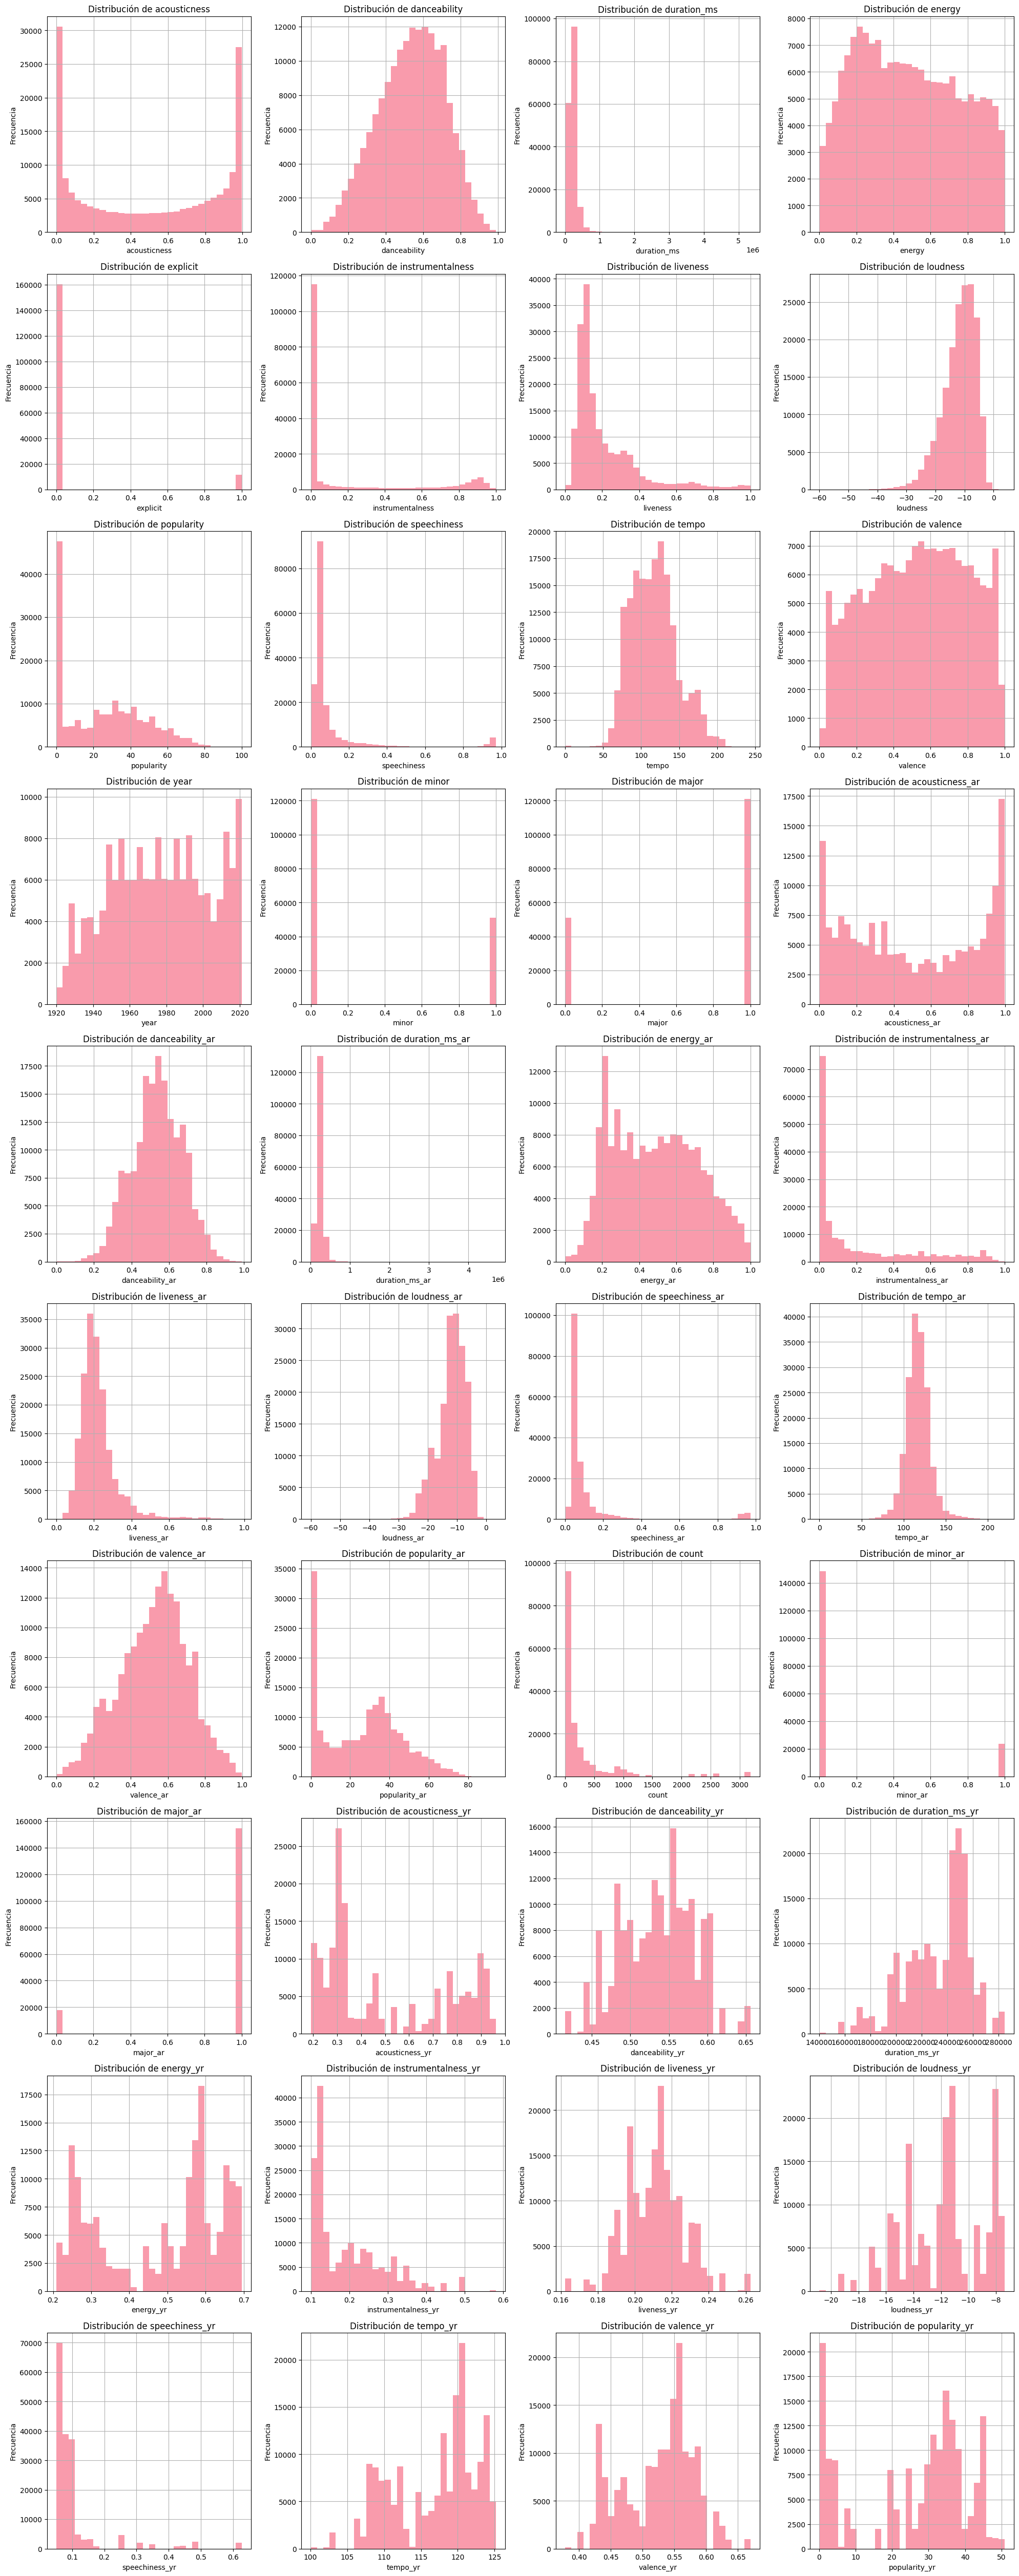

In [63]:

numeric_cols = df[targets].select_dtypes(include=[np.number]).columns
n_cols = len(numeric_cols)

fig, axes = plt.subplots(nrows=(n_cols//4)+1, ncols=4, figsize=(20, 5*((n_cols//4)+1)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')


for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

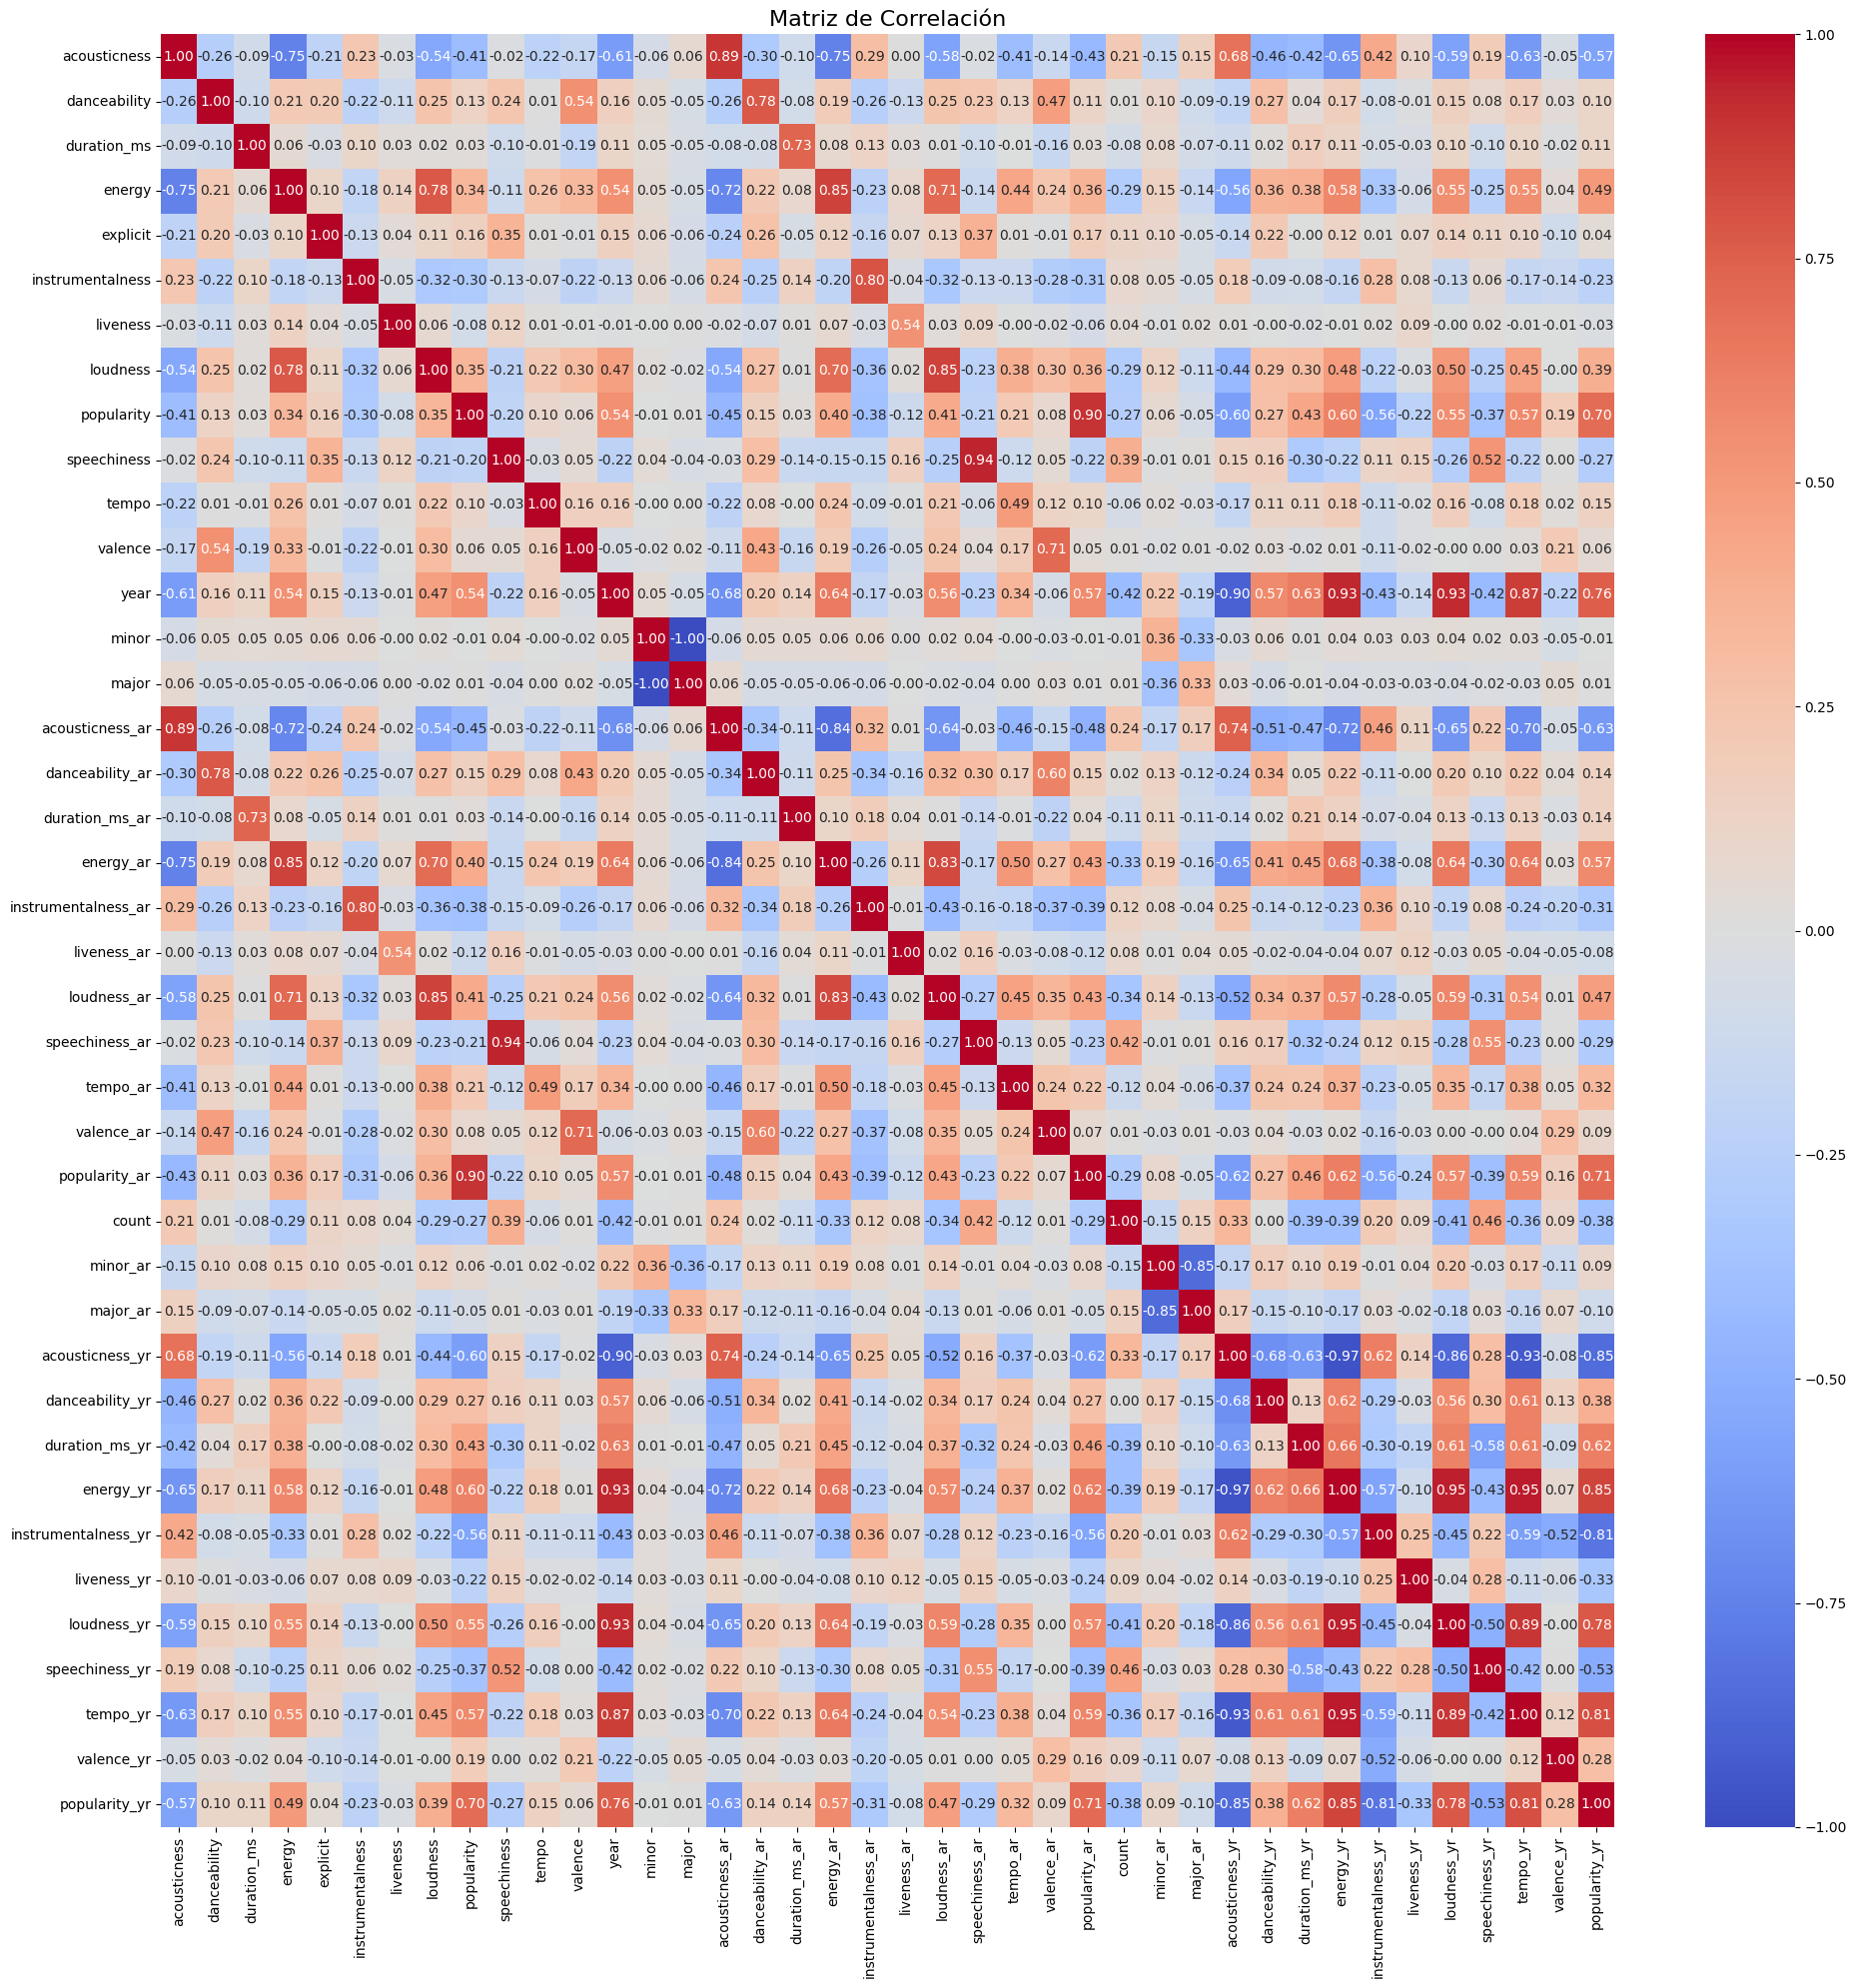

In [64]:

correlation_matrix = df[targets].select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,  
            fmt='.2f')
plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()
plt.show()


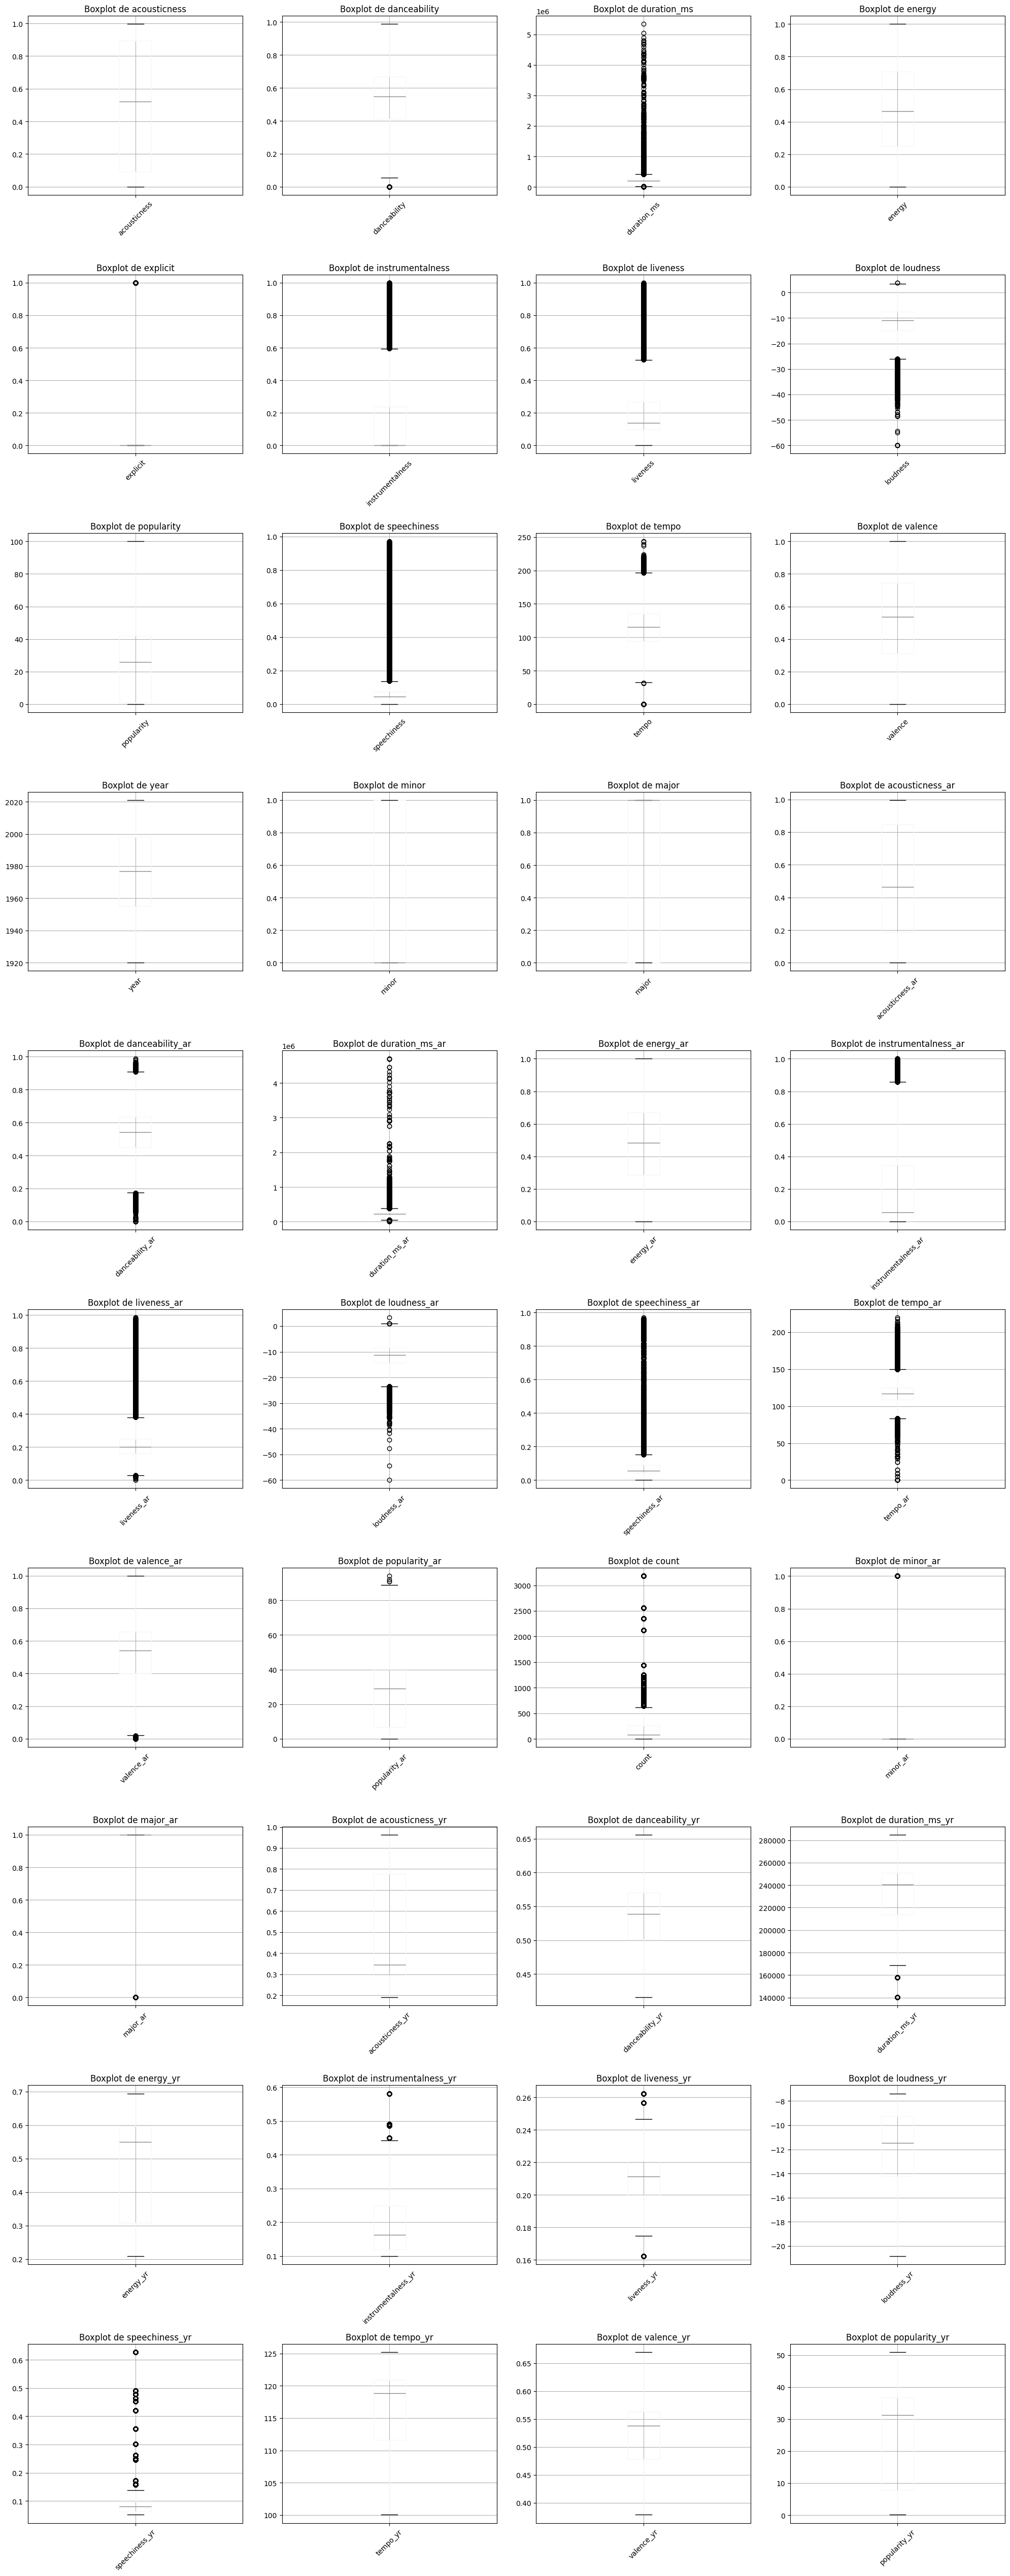


Outliers identificados usando método IQR:
acousticness: 0 outliers (0.00%)
danceability: 120 outliers (0.07%)
duration_ms: 9932 outliers (5.77%)
energy: 0 outliers (0.00%)
explicit: 11704 outliers (6.80%)
instrumentalness: 32628 outliers (18.94%)
liveness: 12297 outliers (7.14%)
loudness: 3248 outliers (1.89%)
popularity: 0 outliers (0.00%)
speechiness: 24362 outliers (14.15%)
tempo: 1766 outliers (1.03%)
valence: 0 outliers (0.00%)
year: 0 outliers (0.00%)
minor: 0 outliers (0.00%)
major: 0 outliers (0.00%)
acousticness_ar: 0 outliers (0.00%)
danceability_ar: 760 outliers (0.44%)
duration_ms_ar: 7126 outliers (4.14%)
energy_ar: 0 outliers (0.00%)
instrumentalness_ar: 7542 outliers (4.38%)
liveness_ar: 9247 outliers (5.37%)
loudness_ar: 2134 outliers (1.24%)
speechiness_ar: 19412 outliers (11.27%)
tempo_ar: 5247 outliers (3.05%)
valence_ar: 103 outliers (0.06%)
popularity_ar: 4 outliers (0.00%)
count: 21555 outliers (12.52%)
minor_ar: 23606 outliers (13.71%)
major_ar: 17798 outliers (

In [65]:

numeric_cols = df[targets].select_dtypes(include=[np.number]).columns
n_cols = len(numeric_cols)

fig, axes = plt.subplots(nrows=(n_cols//4)+1, ncols=4, figsize=(20, 5*((n_cols//4)+1)))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df.boxplot(column=col, ax=axes[i])
        axes[i].set_title(f'Boxplot de {col}')
        axes[i].tick_params(axis='x', rotation=45)

for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print("\nOutliers identificados usando método IQR:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

In [7]:
df_artist.shape

(32539, 15)

In [8]:
df_genre.shape

(32539, 16)

In [9]:
df_year.shape

(102, 14)

In [10]:
df_data.shape

(174389, 19)

In [11]:
df.shape

(172230, 72)

In [12]:

df_artist.head()

,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,"""Cats"" 1981 Original London Cast",0.598500,0.470100,267072.000000,0.376203,0.010261,0.283050,-14.434300,0.209150,114.128800,0.358320,38.200000,5,1,10
1,"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,31.538462,5,1,26
2,"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.571429,0,1,7
3,"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.407407,0,1,27
4,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,42.000000,5,1,7


In [13]:
df_artist.tail()

,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
32534,김효근,0.939,0.1740,341821.0,0.3210,0.756000,0.6950,-13.4110,0.0422,138.300,0.0554,0.0,3,1,1
32535,나율,0.717,0.5915,241281.5,0.4735,0.000000,0.1050,-6.5885,0.0537,107.599,0.5075,16.0,1,1,4
32536,미스티,0.416,0.6860,216715.0,0.8220,0.000000,0.1100,-6.3000,0.0802,122.047,0.6250,0.0,5,0,2
32537,시온 Zion & 한해 Hanhae of 팬텀 Phantom,0.288,0.7390,242480.0,0.4750,0.000000,0.0757,-8.9200,0.3790,81.490,0.8000,8.0,2,0,2
32538,조정현,0.568,0.4470,237688.0,0.2150,0.000001,0.0649,-16.4780,0.0272,71.979,0.1770,30.0,10,1,2


In [16]:
df_data.head()

,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.991000,['Mamie Smith'],0.598,168333,0.224,0,0cS0A1fUEUd1EW3FcF8AEI,0.000522,5,0.3790,-12.628,0,Keep A Song In Your Soul,12,1920,0.0936,149.976,0.6340,1920
1,0.643000,"[""Screamin' Jay Hawkins""]",0.852,150200,0.517,0,0hbkKFIJm7Z05H8Zl9w30f,0.026400,5,0.0809,-7.261,0,I Put A Spell On You,7,1920-01-05,0.0534,86.889,0.9500,1920
2,0.993000,['Mamie Smith'],0.647,163827,0.186,0,11m7laMUgmOKqI3oYzuhne,0.000018,0,0.5190,-12.098,1,Golfing Papa,4,1920,0.1740,97.600,0.6890,1920
3,0.000173,['Oscar Velazquez'],0.730,422087,0.798,0,19Lc5SfJJ5O1oaxY0fpwfh,0.801000,2,0.1280,-7.311,1,True House Music - Xavier Santos & Carlos Gomi...,17,1920-01-01,0.0425,127.997,0.0422,1920
4,0.295000,['Mixe'],0.704,165224,0.707,1,2hJjbsLCytGsnAHfdsLejp,0.000246,10,0.4020,-6.036,0,Xuniverxe,2,1920-10-01,0.0768,122.076,0.2990,1920


In [17]:
df_genre.head()

,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count,genres
0,"""Cats"" 1981 Original London Cast",0.598500,0.470100,267072.000000,0.376203,0.010261,0.283050,-14.434300,0.209150,114.128800,0.358320,38.200000,5,1,10,['show tunes']
1,"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,31.538462,5,1,26,[]
2,"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.571429,0,1,7,[]
3,"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.407407,0,1,27,[]
4,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,42.000000,5,1,7,[]
